# Диплом: KAN для прогнозирования энергопотребления

Черновой ноутбук для финальной экспериментальной части диплома.

Идея: проверить KAN и базовые модели на публичном датасете `ElectricityLoadDiagrams20112014` (UCI) в задаче краткосрочного прогнозирования нагрузки.

## 1. Импорты и настройки

In [1]:
import io
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00321/LD2011_2014.txt.zip"
LOCAL_TXT = "LD2011_2014.txt"

WINDOW = 24 * 7
HORIZON = 24
BATCH_SIZE = 256
EPOCHS = 30
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

Device: cpu


## 2. Загрузка датасета UCI

In [3]:
def load_electricity_dataset(local_txt=LOCAL_TXT, url=DATA_URL):
    try:
        df = pd.read_csv(local_txt, sep=";", decimal=",")
        print("Файл найден локально:", local_txt)
        return df
    except FileNotFoundError:
        print("Локальный файл не найден, пробуем скачать с UCI...")
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
            filename = [name for name in zf.namelist() if name.endswith('.txt')][0]
            with zf.open(filename) as f:
                df = pd.read_csv(f, sep=";", decimal=",")
        return df

raw_df = load_electricity_dataset()
raw_df.head()

Файл найден локально: LD2011_2014.txt


,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Подготовка данных

Для первой версии дипломного эксперимента берём агрегированную нагрузку по всем клиентам и календарные признаки. Это упрощает постановку, ускоряет обучение и делает результаты легче интерпретируемыми.

In [4]:
df = raw_df.rename(columns={raw_df.columns[0]: "datetime"}).copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime")

load_cols = df.columns.tolist()
df[load_cols] = df[load_cols].fillna(0)

hourly = pd.DataFrame(index=df.resample("1H").sum().index)
hourly["total_load_kw"] = df[load_cols].sum(axis=1).resample("1H").mean()
hourly["hour"] = hourly.index.hour
hourly["dayofweek"] = hourly.index.dayofweek
hourly["month"] = hourly.index.month
hourly["is_weekend"] = (hourly.index.dayofweek >= 5).astype(int)
hourly["sin_hour"] = np.sin(2 * np.pi * hourly["hour"] / 24)
hourly["cos_hour"] = np.cos(2 * np.pi * hourly["hour"] / 24)
hourly["sin_dow"] = np.sin(2 * np.pi * hourly["dayofweek"] / 7)
hourly["cos_dow"] = np.cos(2 * np.pi * hourly["dayofweek"] / 7)
hourly = hourly.dropna().copy()

hourly.head()

,total_load_kw,hour,dayofweek,month,is_weekend,sin_hour,cos_hour,sin_dow,cos_dow
datetime,,,,,,,,,
2011-01-01 00:00:00,69019.423424,0,5,1,1,0.000000,1.000000,-0.974928,-0.222521
2011-01-01 01:00:00,66344.627687,1,5,1,1,0.258819,0.965926,-0.974928,-0.222521
2011-01-01 02:00:00,65981.054883,2,5,1,1,0.500000,0.866025,-0.974928,-0.222521
2011-01-01 03:00:00,66576.533566,3,5,1,1,0.707107,0.707107,-0.974928,-0.222521
2011-01-01 04:00:00,64963.552675,4,5,1,1,0.866025,0.500000,-0.974928,-0.222521


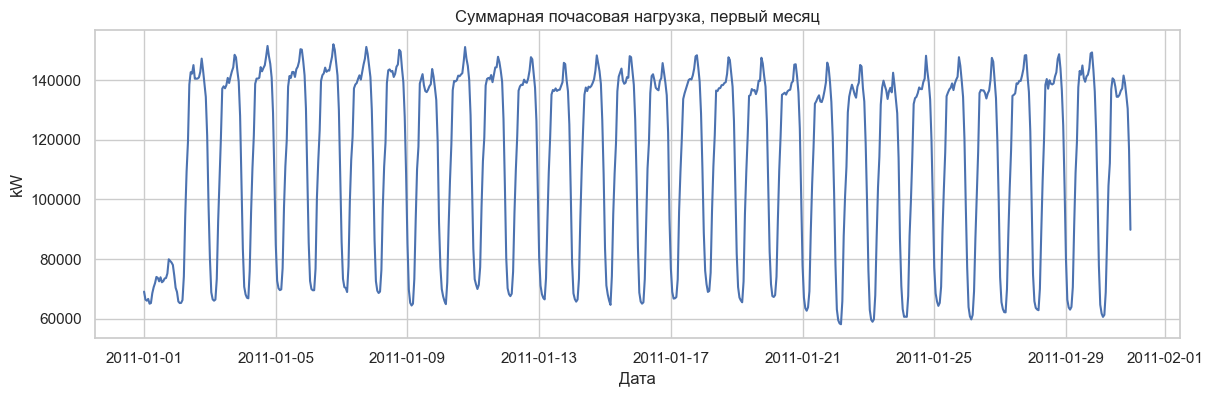

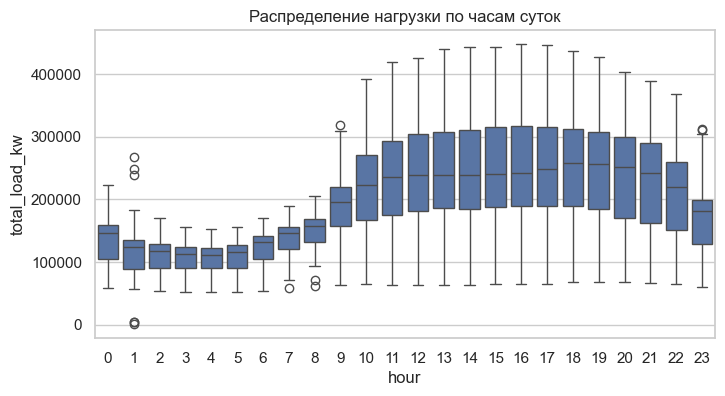

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(hourly.index[:24 * 30], hourly["total_load_kw"][:24 * 30])
plt.title("Суммарная почасовая нагрузка, первый месяц")
plt.xlabel("Дата")
plt.ylabel("kW")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=hourly["hour"], y=hourly["total_load_kw"])
plt.title("Распределение нагрузки по часам суток")
plt.show()

## 4. Подготовка выборок для прогнозирования

In [6]:
feature_cols = [
    "total_load_kw",
    "hour",
    "dayofweek",
    "month",
    "is_weekend",
    "sin_hour",
    "cos_hour",
    "sin_dow",
    "cos_dow",
]

target_col = "total_load_kw"

split_idx = int(len(hourly) * 0.8)
train_df = hourly.iloc[:split_idx].copy()
test_df = hourly.iloc[split_idx:].copy()

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

target_idx = feature_cols.index(target_col)

def make_windows(data, window, horizon, target_index):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i:i + window])
        y.append(data[i + window:i + window + horizon, target_index])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_scaled, WINDOW, HORIZON, target_idx)
X_test, y_test = make_windows(test_scaled, WINDOW, HORIZON, target_idx)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([27861, 168, 9])
y_train: torch.Size([27861, 24])
X_test: torch.Size([6822, 168, 9])
y_test: torch.Size([6822, 24])


## 5. Модели

In [7]:
class KANLayer(nn.Module):
    def __init__(self, in_dim, out_dim, num_basis=16):
        super().__init__()
        self.knots = nn.Parameter(torch.linspace(-3, 3, num_basis), requires_grad=False)
        self.coeffs = nn.Parameter(torch.randn(in_dim, out_dim, num_basis) * 0.05)

    def forward(self, x):
        x = x.unsqueeze(-1)
        basis = torch.exp(-(x - self.knots) ** 2)
        return torch.einsum("bin,ion->bo", basis, self.coeffs)


class KANForecaster(nn.Module):
    def __init__(self, window, n_features, hidden=64, horizon=24):
        super().__init__()
        input_dim = window * n_features
        self.kan1 = KANLayer(input_dim, hidden)
        self.kan2 = KANLayer(hidden, horizon)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.kan1(x)
        x = self.kan2(x)
        return x


class MLPForecaster(nn.Module):
    def __init__(self, window, n_features, hidden=128, horizon=24):
        super().__init__()
        input_dim = window * n_features
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, horizon),
        )

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))


class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden=64, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class HybridKANForecaster(nn.Module):
    def __init__(self, window, n_features, hidden=64, horizon=24):
        super().__init__()
        input_dim = window * n_features
        self.linear = nn.Linear(input_dim, horizon)
        self.kan1 = KANLayer(input_dim, hidden)
        self.kan2 = KANLayer(hidden, horizon)

    def forward(self, x):
        flat = x.view(x.size(0), -1)
        return self.linear(flat) + self.kan2(self.kan1(flat))

## 6. Обучение и оценка

In [8]:
def iterate_minibatches(X, y, batch_size=BATCH_SIZE, shuffle=True):
    idx = np.arange(len(X))
    if shuffle:
        np.random.shuffle(idx)
    for start in range(0, len(X), batch_size):
        batch_idx = idx[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]


def train_model(model, X_train, y_train, epochs=EPOCHS, lr=LR):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        for xb, yb in iterate_minibatches(X_train, y_train):
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        history.append(float(np.mean(epoch_losses)))
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch + 1}/{epochs} | loss={history[-1]:.5f}")

    return history


def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        preds = model(X_test.to(DEVICE)).cpu().numpy()
    true = y_test.numpy()

    rmse = np.sqrt(mean_squared_error(true.reshape(-1), preds.reshape(-1)))
    mae = mean_absolute_error(true.reshape(-1), preds.reshape(-1))
    mape = np.mean(np.abs((true.reshape(-1) - preds.reshape(-1)) / (true.reshape(-1) + 1e-8))) * 100
    r2 = r2_score(true.reshape(-1), preds.reshape(-1))
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}, preds

In [10]:
models = {
    "KAN": KANForecaster(WINDOW, len(feature_cols), hidden=64, horizon=HORIZON),
    "MLP": MLPForecaster(WINDOW, len(feature_cols), hidden=128, horizon=HORIZON),
    "LSTM": LSTMForecaster(len(feature_cols), hidden=64, horizon=HORIZON),
    "Hybrid KAN": HybridKANForecaster(WINDOW, len(feature_cols), hidden=64, horizon=HORIZON),
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"\n{name}")
    _ = train_model(model, X_train, y_train)
    metrics, preds = evaluate_model(model, X_test, y_test)
    results[name] = metrics
    predictions[name] = preds

results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df


KAN
Epoch 5/30 | loss=0.03191
Epoch 10/30 | loss=0.02573
Epoch 15/30 | loss=0.06734
Epoch 20/30 | loss=0.03816
Epoch 25/30 | loss=0.06470
Epoch 30/30 | loss=0.03765

MLP
Epoch 5/30 | loss=0.01760
Epoch 10/30 | loss=0.01392
Epoch 15/30 | loss=0.01297
Epoch 20/30 | loss=0.01174
Epoch 25/30 | loss=0.01137
Epoch 30/30 | loss=0.01073

LSTM
Epoch 5/30 | loss=0.02124
Epoch 10/30 | loss=0.01758
Epoch 15/30 | loss=0.01594
Epoch 20/30 | loss=0.01463
Epoch 25/30 | loss=0.01338
Epoch 30/30 | loss=0.01250

Hybrid KAN
Epoch 5/30 | loss=0.01980
Epoch 10/30 | loss=0.01625
Epoch 15/30 | loss=0.01543
Epoch 20/30 | loss=0.01503
Epoch 25/30 | loss=0.01520
Epoch 30/30 | loss=0.01519


,RMSE,MAE,MAPE,R2
MLP,0.136151,0.091998,23.965250,0.982558
Hybrid KAN,0.148407,0.097176,24.643900,0.979276
LSTM,0.150409,0.103989,28.841746,0.978713
KAN,0.227137,0.173118,60.573012,0.951456


## 7. Визуализация прогноза

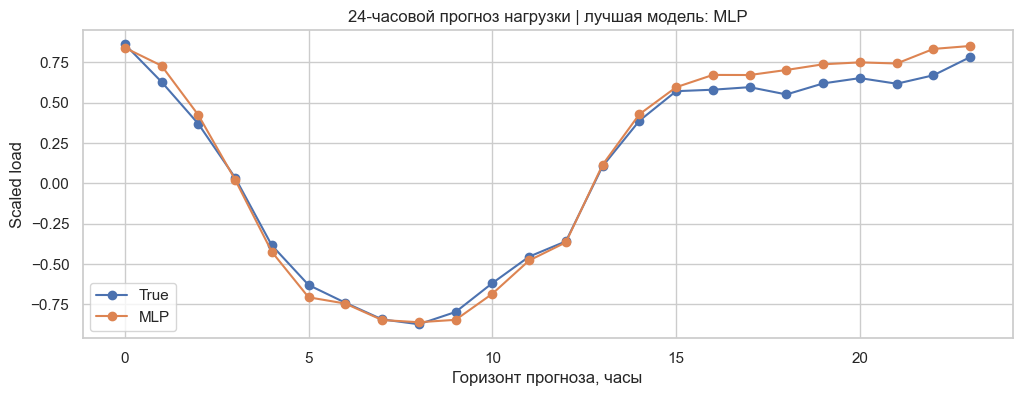

: 

In [ ]:
best_model_name = results_df.index[0]
best_preds = predictions[best_model_name]

sample_id = 0
plt.figure(figsize=(12, 4))
plt.plot(y_test[sample_id].numpy(), label="True", marker="o")
plt.plot(best_preds[sample_id], label=best_model_name, marker="o")
plt.title(f"24-часовой прогноз нагрузки | лучшая модель: {best_model_name}")
plt.xlabel("Горизонт прогноза, часы")
plt.ylabel("Scaled load")
plt.legend()
plt.show()

## 8. Что добавить в следующей версии ноутбука

1. Эксперименты при разных горизонтах (`1`, `6`, `12`, `24`, `48` часов).
2. Проверку устойчивости при шуме, пропусках и уменьшенной обучающей выборке.
3. Визуализацию `phi`-функций KAN для интерпретации.
4. Абляцию по числу базисов, скрытому размеру и длине окна.
5. Сравнение с `XGBoost` или `LightGBM` на табличном представлении лагов.